# Sanskrit Pairwise Similarity Starter

Demonstrates two-text pairwise sentence similarity using `SanskritResearchSDK`.

**Workflow:**
1. Segment both texts with the DandasSegmenter
2. Embed all sentence segments with `buddhist-nlp/gemma-2-mitra-e`
3. Compute cosine similarity matrix
4. Inspect the top-k sentence-pair matches

**Note:** First run will download the Gemma Mitra model (~5 GB). Run `python scripts/download_gemma_mitra.py` beforehand for a reliable download.

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sanskrit_pipeline.sdk import SanskritResearchSDK
from sanskrit_pipeline.embeddings import DEFAULT_MODEL_ID

print(f"Default model: {DEFAULT_MODEL_ID}")

Default model: buddhist-nlp/gemma-2-mitra-e


In [4]:
sdk = SanskritResearchSDK(
    engine="dandas",
    source_format="devanagari",
    model_id=DEFAULT_MODEL_ID,
    device="cpu", #"auto",        # auto-selects CUDA > MPS > CPU
    batch_size=8,
    embedding_progress="batch",
)

In [5]:
# Two short Sanskrit texts for comparison
# Replace these with real corpus texts from your data directory

# Sample Sanskrit text — Bhagavad Gita 2.47-2.48
text_a = """
कर्मण्येवाधिकारस्ते मा फलेषु कदाचन।
मा कर्मफलहेतुर्भूर्मा ते सङ्गोऽस्त्वकर्मणि॥
योगस्थः कुरु कर्माणि सङ्गं त्यक्त्वा धनंजय।
सिद्ध्यसिद्ध्योः समो भूत्वा समत्वं योग उच्यते॥
"""
# Sample Sanskrit text — Manusmriti (8.15), Mundaka Upanishad (3.1.6), Mahabharata, Bhagavad Gita 2.50
text_b = """
धर्मो रक्षति रक्षितः।
सत्यमेव जयते नानृतम्।
अहिंसा परमो धर्मः।
योगः कर्मसु कौशलम्॥
"""

print(f"Text A length: {len(text_a)} chars")
print(f"Text B length: {len(text_b)} chars")

Text A length: 172 chars
Text B length: 84 chars


In [6]:
# Segmentation preview
seg_a = sdk.segment_text(text_a)
seg_b = sdk.segment_text(text_b)

print(f"Text A segments ({len(seg_a.segments)}):")
for s in seg_a.segments:
    print(f"  {s}")

print(f"\nText B segments ({len(seg_b.segments)}):")
for s in seg_b.segments:
    print(f"  {s}")

Text A segments (2):
  कर्मण्येवाधिकारस्ते मा फलेषु कदाचन। मा कर्मफलहेतुर्भूर्मा ते सङ्गोऽस्त्वकर्मणि॥
  योगस्थः कुरु कर्माणि सङ्गं त्यक्त्वा धनंजय। सिद्ध्यसिद्ध्योः समो भूत्वा समत्वं योग उच्यते॥

Text B segments (1):
  धर्मो रक्षति रक्षितः। सत्यमेव जयते नानृतम्। अहिंसा परमो धर्मः। योगः कर्मसु कौशलम्॥


In [7]:
# Embed both texts (loads the model on first call)
emb_a = sdk.embed_sentences(seg_a.segments, is_query=True)
emb_b = sdk.embed_sentences(seg_b.segments, is_query=False)

print(f"Embeddings A shape: {emb_a.embeddings.shape}")
print(f"Embeddings B shape: {emb_b.embeddings.shape}")
emb_a.to_dataframe().head()

The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 464/464 [00:00<00:00, 11608.66it/s]


[embed] backend=gemma-last-token device=cpu total_sentences=2 batch_size=8 batches=1
[embed] batch 1/1 sentences 1-2/2
[embed] backend=gemma-last-token device=cpu total_sentences=1 batch_size=8 batches=1
[embed] batch 1/1 sentences 1-1/1
Embeddings A shape: (2, 3584)
Embeddings B shape: (1, 3584)


,sentence_index,sentence_text,vector_norm
0,0,कर्मण्येवाधिकारस्ते मा फलेषु कदाचन। मा कर्मफलह...,1.0
1,1,योगस्थः कुरु कर्माणि सङ्गं त्यक्त्वा धनंजय। सि...,1.0


In [8]:
# Pairwise similarity from pre-computed embeddings (no re-embedding)
pairwise_view = sdk.pairwise_from_embedding_views(emb_a, emb_b, top_k=10)

print(f"Similarity matrix shape: {pairwise_view.similarity_matrix.shape}")
print(f"Max score: {pairwise_view.metrics.max_score:.4f}")
print(f"Mean best A→B: {pairwise_view.metrics.mean_best_a_to_b:.4f}")
pairwise_view.topk_dataframe()

Similarity matrix shape: (2, 1)
Max score: 0.4420
Mean best A→B: 0.3319


,rank,score,i,j,sentence_a,sentence_b
0,1,0.441955,1,0,योगस्थः कुरु कर्माणि सङ्गं त्यक्त्वा धनंजय। सि...,धर्मो रक्षति रक्षितः। सत्यमेव जयते नानृतम्। अह...
1,2,0.221886,0,0,कर्मण्येवाधिकारस्ते मा फलेषु कदाचन। मा कर्मफलह...,धर्मो रक्षति रक्षितः। सत्यमेव जयते नानृतम्। अह...


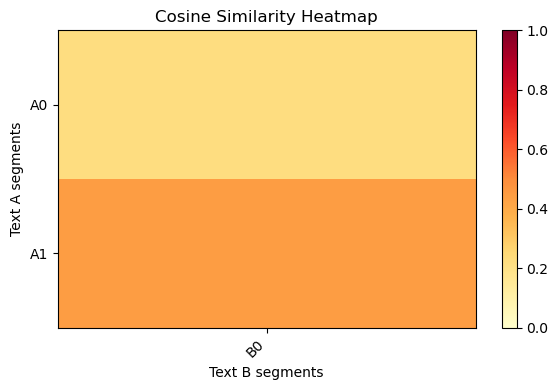

In [9]:
import matplotlib.pyplot as plt
import numpy as np

matrix = pairwise_view.similarity_matrix
fig, ax = plt.subplots(figsize=(max(6, len(seg_b.segments)), max(4, len(seg_a.segments))))
im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(seg_b.segments)))
ax.set_xticklabels([f"B{i}" for i in range(len(seg_b.segments))], rotation=45, ha="right")
ax.set_yticks(range(len(seg_a.segments)))
ax.set_yticklabels([f"A{i}" for i in range(len(seg_a.segments))])
ax.set_xlabel("Text B segments")
ax.set_ylabel("Text A segments")
ax.set_title("Cosine Similarity Heatmap")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()